In [9]:

import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from wordcloud import WordCloud, STOPWORDS
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import json, numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification


In [10]:
df_beyondblue = pd.read_csv('beyondblue_goemotions_ekman.csv')
df_beyondblue.head()

,Unnamed: 0,keyword,post_content_preview,thread_url,post_date,comments,num_comments,post_content_preview_clean,comments_clean,post_length,...,goe_sum_active,goe_ekman_anger_prob,goe_ekman_disgust_prob,goe_ekman_fear_prob,goe_ekman_joy_prob,goe_ekman_sadness_prob,goe_ekman_surprise_prob,goe_ekman_neutral_prob,goe_ekman_top3,goe_ekman_dominant
0,0,anxiety,Hi my name is Michelle and I have hadAnxietymy...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎23-05-2025,"[""Dear Michelle ~Welcome here to the Support F...",2,michelle hadanxietymy life usually able contro...,dear michelle welcome good step anxiety coped ...,200,...,1,0.009054,0.007664,0.278498,0.008877,0.047562,0.007411,0.081820,"[[""fear"", 0.2784978747367859], [""neutral"", 0.0...",fear
1,1,anxiety,"Hi, I’ve suffered on and off fromanxietyover...",https://forums.beyondblue.org.au/t5/welcome-an...,‎28-05-2025,['Hello new member and welcome to the forum.Pl...,4,suffered fromanxietyover life recent years rea...,new member welcome forumplease arrived place n...,173,...,2,0.006025,0.002521,0.223599,0.011015,0.077257,0.010349,0.071989,"[[""fear"", 0.22359919548034668], [""sadness"", 0....",fear
2,2,anxiety,"I have had chronicanxietysince 2016, but I hav...",https://forums.beyondblue.org.au/t5/anxiety/an...,‎06-01-2025,"['Dear Guest-65543263,I can very much relate t...",9,chronicanxietysince managed bay medicationexer...,dear guest relate written perimenopause sympto...,186,...,1,0.003594,0.003397,0.015084,0.003627,0.003881,0.005419,0.911917,"[[""neutral"", 0.9119173288345337], [""fear"", 0.0...",neutral
3,3,anxiety,Hello I struggle with very badanxietyand panic...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-03-2025,"['Hello any advice please would help', ""Hi don...",4,struggle badanxietyand panic attacks finally g...,advice ashamed struggle tell struggling helps ...,197,...,1,0.006177,0.003840,0.370488,0.027017,0.025674,0.013829,0.053419,"[[""fear"", 0.37048792839050293], [""neutral"", 0....",fear
4,4,anxiety,I’ve recently sold my mortgage free home that ...,https://forums.beyondblue.org.au/t5/anxiety/an...,‎04-06-2025,"[""Hi KCT welcomeAnxiety is a serious condition...",3,recently sold mortgage free home lived years c...,kct welcomeanxiety condition underestimated po...,192,...,1,0.002832,0.004036,0.024528,0.005882,0.026403,0.008590,0.737784,"[[""neutral"", 0.7377844452857971], [""sadness"", ...",neutral


In [11]:
LEX_PATH="NRC-VAD-Lexicon-v2.1.txt"

In [12]:
from collections import defaultdict

# Recalculate V/A per post from scratch using a VAD lexicon
#
# - Adds columns: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant,
#                 va_title_hits, va_body_hits, va_title_cov, va_body_cov
#
# Config / overrides:
MANUAL_OVERRIDES = {
    # example: 'battery': (0.5, 0.5),
    # put any token: (valence, arousal) in 0..1 here to force values
}
OUT_MODE = "clip"   # "clip" (default) or "halve"

# ---------- helpers ----------
negation_tokens = {"not","no","never","n't","cannot","neither","nor"}
intensifiers = {"very","really","so","extremely","highly","super","too","quite"}

# Config / overrides:
MANUAL_OVERRIDES = MANUAL_OVERRIDES  # keep existing notebook value
OUT_MODE = OUT_MODE                  # keep existing notebook value

# ---------- helpers ----------
negation_tokens = negation_tokens    # reuse existing
intensifiers = intensifiers          # reuse existing

def load_vad_norm(path):
    # robust loader: find word/valence/arousal columns, normalize to 0..1
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [str(c).strip().lower() for c in df.columns]
    word_col = next((c for c in df.columns if c in ("word","term","lemma")), None)
    val_col = next((c for c in df.columns if c in ("valence","v","val")), None)
    aro_col = next((c for c in df.columns if c in ("arousal","a","aro")), None)
    if word_col is None or val_col is None or aro_col is None:
        df2 = pd.read_csv(path, header=None, sep=None, engine="python")
        df2.columns = [f"col{i}" for i in range(df2.shape[1])]
        word_col = next((c for c in df2.columns if pd.to_numeric(df2[c], errors="coerce").isna().mean() > 0.5), df2.columns[0])
        num_cols = [c for c in df2.columns if pd.to_numeric(df2[c], errors="coerce").notna().mean() > 0.9]
        if len(num_cols) < 2:
            raise RuntimeError("Could not detect V/A columns in lexicon.")
        val_col, aro_col = num_cols[0], num_cols[1]
        df = df2
    lex = df[[word_col, val_col, aro_col]].copy()
    lex.columns = ["word","val_raw","aro_raw"]
    lex["word"] = lex["word"].astype(str).str.lower().str.strip()
    lex["val_raw"] = pd.to_numeric(lex["val_raw"], errors="coerce")
    lex["aro_raw"] = pd.to_numeric(lex["aro_raw"], errors="coerce")
    lex = lex.dropna()
    vmin, vmax = float(lex["val_raw"].min()), float(lex["val_raw"].max())
    amin, amax = float(lex["aro_raw"].min()), float(lex["aro_raw"].max())
    def normalize_series(smin, smax, arr):
        if smax <= 1.0 and smin >= 0.0:
            return arr.astype(float)
        if smax > 1.5:
            if smin >= 1.0:
                return (arr - 1.0) / (smax - 1.0)
            if smin < 0.0 and abs(smin + 1.0) < 1e-2 and abs(smax - 1.0) < 1e-2:
                return (arr + 1.0) / 2.0
            return (arr - smin) / max(1e-9, (smax - smin))
        else:
            return (arr - smin) / max(1e-9, (smax - smin))
    lex["valence"] = normalize_series(vmin, vmax, lex["val_raw"])
    lex["arousal"] = normalize_series(amin, amax, lex["aro_raw"])
    vdict_local = dict(zip(lex["word"], lex["valence"].astype(float)))
    adict_local = dict(zip(lex["word"], lex["arousal"].astype(float)))
    return vdict_local, adict_local, lex

# reload lexicon into local dicts to ensure consistent names (uses LEX_PATH from notebook)
vdict, adict, lex_df = load_vad_norm(LEX_PATH)

# apply manual overrides into dicts (force tokens --> values)
for k, (vv, aa) in MANUAL_OVERRIDES.items():
    k2 = str(k).lower().strip()
    vdict[k2] = float(vv)
    adict[k2] = float(aa)

def tokenize_field(text):
    if not isinstance(text, str) or not text:
        return []
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\[([^\]]+)\]\([^\)]+\)", r"\1", text)
    text = re.sub(r"(?:u\/|r\/)([A-Za-z0-9_-]+)", r"\1", text)
    text = text.lower()
    toks = re.findall(r"[a-z][a-z']+", text)
    return toks

def clamp01(x):
    return max(0.0, min(1.0, float(x)))

def adjust_value_out_of_range(v, mode="clip"):
    if mode == "clip":
        return max(-1.0, min(1.0, float(v)))
    elif mode == "halve":
        v = float(v)
        iter_guard = 0
        while abs(v) > 1.0 and iter_guard < 50:
            excess = abs(v) - 1.0
            v = (1.0 - 0.5 * excess) * (1.0 if v > 0 else -1.0)
            iter_guard += 1
        return max(-1.0, min(1.0, v))
    else:
        raise ValueError("OUT_MODE must be 'clip' or 'halve'")

# ---------- pick fields for df_beyondblue ----------
body_col = next((c for c in ("post_content_preview_clean","post_content_preview","post_text_lemmas","post_content") if c in df_beyondblue.columns), None)
# assume there's no separate title column in this dataset
title_col = next((c for c in ("title","post_title","thread_title") if c in df_beyondblue.columns), None)

if body_col is None and title_col is None:
    raise RuntimeError("No body/title columns found in df_beyondblue.")

# ---------- compute V/A per field ----------
def compute_field_scores(series_texts):
    vals = []
    aros = []
    hits = []
    covs = []
    for text in series_texts:
        toks = tokenize_field(text)
        if len(toks) == 0:
            vals.append(np.nan); aros.append(np.nan); hits.append(0); covs.append(0.0); continue
        v_sum = 0.0; a_sum = 0.0; count = 0
        total_tokens = len(toks)
        for i, tok in enumerate(toks):
            tok = tok.lower()
            if tok in MANUAL_OVERRIDES:
                base_v, base_a = MANUAL_OVERRIDES[tok]
            else:
                base_v = vdict.get(tok, None)
                base_a = adict.get(tok, None)
            if base_v is None or base_a is None:
                continue
            start = max(0, i - 3)
            prev = toks[start:i]
            if any(p in negation_tokens for p in prev):
                base_v = 1.0 - base_v
            if any(p in intensifiers for p in prev):
                base_v = 0.5 + 1.25 * (base_v - 0.5)
                base_a = 0.5 + 1.25 * (base_a - 0.5)
            base_v = clamp01(base_v)
            base_a = clamp01(base_a)
            v_sum += base_v
            a_sum += base_a
            count += 1
        if count > 0:
            vals.append(v_sum / count)
            aros.append(a_sum / count)
            hits.append(count)
            covs.append(100.0 * (count / total_tokens))
        else:
            vals.append(np.nan)
            aros.append(np.nan)
            hits.append(0)
            covs.append(0.0)
    return pd.Series(vals, index=series_texts.index, dtype="float32"), \
           pd.Series(aros, index=series_texts.index, dtype="float32"), \
           pd.Series(hits, index=series_texts.index, dtype="int32"), \
           pd.Series(covs, index=series_texts.index, dtype="float32")

# compute for title and body (if present)
title_vals = title_aros = title_hits = title_cov = None
body_vals = body_aros = body_hits = body_cov = None

if title_col is not None:
    title_vals, title_aros, title_hits, title_cov = compute_field_scores(df_beyondblue[title_col].fillna(""))
else:
    title_vals = pd.Series(np.nan, index=df_beyondblue.index, dtype="float32")
    title_aros = pd.Series(np.nan, index=df_beyondblue.index, dtype="float32")
    title_hits = pd.Series(0, index=df_beyondblue.index, dtype="int32")
    title_cov = pd.Series(0.0, index=df_beyondblue.index, dtype="float32")

if body_col is not None:
    body_vals, body_aros, body_hits, body_cov = compute_field_scores(df_beyondblue[body_col].fillna(""))
else:
    body_vals = pd.Series(np.nan, index=df_beyondblue.index, dtype="float32")
    body_aros = pd.Series(np.nan, index=df_beyondblue.index, dtype="float32")
    body_hits = pd.Series(0, index=df_beyondblue.index, dtype="int32")
    body_cov = pd.Series(0.0, index=df_beyondblue.index, dtype="float32")

# ---------- combine title + body into post-level V/A using token-count weighting ----------
va_val = []
va_aro = []
for i in df_beyondblue.index:
    vt, at = title_vals.loc[i], title_aros.loc[i]
    vb, ab = body_vals.loc[i], body_aros.loc[i]
    nt, nb = int(title_hits.loc[i]), int(body_hits.loc[i])
    if (np.isnan(vt) or nt == 0) and (np.isnan(vb) or nb == 0):
        va_val.append(np.nan); va_aro.append(np.nan); continue
    if (np.isnan(vt) or nt == 0) and (not np.isnan(vb) and nb > 0):
        va_val.append(float(vb)); va_aro.append(float(ab)); continue
    if (np.isnan(vb) or nb == 0) and (not np.isnan(vt) and nt > 0):
        va_val.append(float(vt)); va_aro.append(float(at)); continue
    wsum = nt + nb
    v_comb = (vt * nt + vb * nb) / wsum
    a_comb = (at * nt + ab * nb) / wsum
    va_val.append(float(v_comb))
    va_aro.append(float(a_comb))

va_val = pd.Series(va_val, index=df_beyondblue.index, dtype="float32")
va_aro = pd.Series(va_aro, index=df_beyondblue.index, dtype="float32")

# ---------- map to circumplex and handle out-of-range ----------
va_val_std = 2.0 * va_val - 1.0
va_aro_std = 2.0 * va_aro - 1.0

va_val_std = va_val_std.apply(lambda x: np.nan if pd.isna(x) else adjust_value_out_of_range(x, OUT_MODE))
va_aro_std = va_aro_std.apply(lambda x: np.nan if pd.isna(x) else adjust_value_out_of_range(x, OUT_MODE))

def quadrant_label(vs, ar):
    if pd.isna(vs) or pd.isna(ar):
        return None
    if abs(vs) < 0.1 and abs(ar) < 0.1:
        return "center"
    if vs >= 0 and ar >= 0:
        return "Q1"
    if vs < 0 and ar >= 0:
        return "Q2"
    if vs < 0 and ar < 0:
        return "Q3"
    if vs >= 0 and ar < 0:
        return "Q4"
    return None

va_quadrant = pd.Series([quadrant_label(vs, ar) for vs, ar in zip(va_val_std, va_aro_std)], index=df_beyondblue.index, dtype="object")

# ---------- attach columns to df_beyondblue ----------
df_beyondblue["va_valence"] = va_val
df_beyondblue["va_arousal"] = va_aro
df_beyondblue["va_val_std"] = va_val_std
df_beyondblue["va_aro_std"] = va_aro_std
df_beyondblue["va_quadrant"] = va_quadrant
df_beyondblue["va_title_hits"] = title_hits
df_beyondblue["va_body_hits"] = body_hits
df_beyondblue["va_title_cov"] = title_cov
df_beyondblue["va_body_cov"] = body_cov

# Quick summary prints
print("\nAdded columns to df_beyondblue: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant, va_title_hits, va_body_hits, va_title_cov, va_body_cov")
print(f"Fields used: title_col='{title_col}', body_col='{body_col}'")
print("OUT_MODE =", OUT_MODE)
display_cols = ["va_valence","va_arousal","va_val_std","va_aro_std","va_quadrant","va_title_hits","va_body_hits","va_title_cov","va_body_cov"]
print(df_beyondblue[display_cols].head(6))



Added columns to df_beyondblue: va_valence, va_arousal, va_val_std, va_aro_std, va_quadrant, va_title_hits, va_body_hits, va_title_cov, va_body_cov
Fields used: title_col='None', body_col='post_content_preview_clean'
OUT_MODE = clip
   va_valence  va_arousal  va_val_std  va_aro_std va_quadrant  va_title_hits  \
0    0.589350    0.519650    0.178700    0.039300          Q1              0   
1    0.625911    0.539946    0.251821    0.079893          Q1              0   
2    0.701900    0.434300    0.403800   -0.131400          Q4              0   
3    0.614857    0.522000    0.229714    0.044000          Q1              0   
4    0.675462    0.433346    0.350923   -0.133308          Q4              0   
5    0.509818    0.406045    0.019636   -0.187909          Q4              0   

   va_body_hits  va_title_cov  va_body_cov  
0            10           0.0    71.428574  
1             7           0.0    70.000000  
2             5           0.0    55.555557  
3             7          

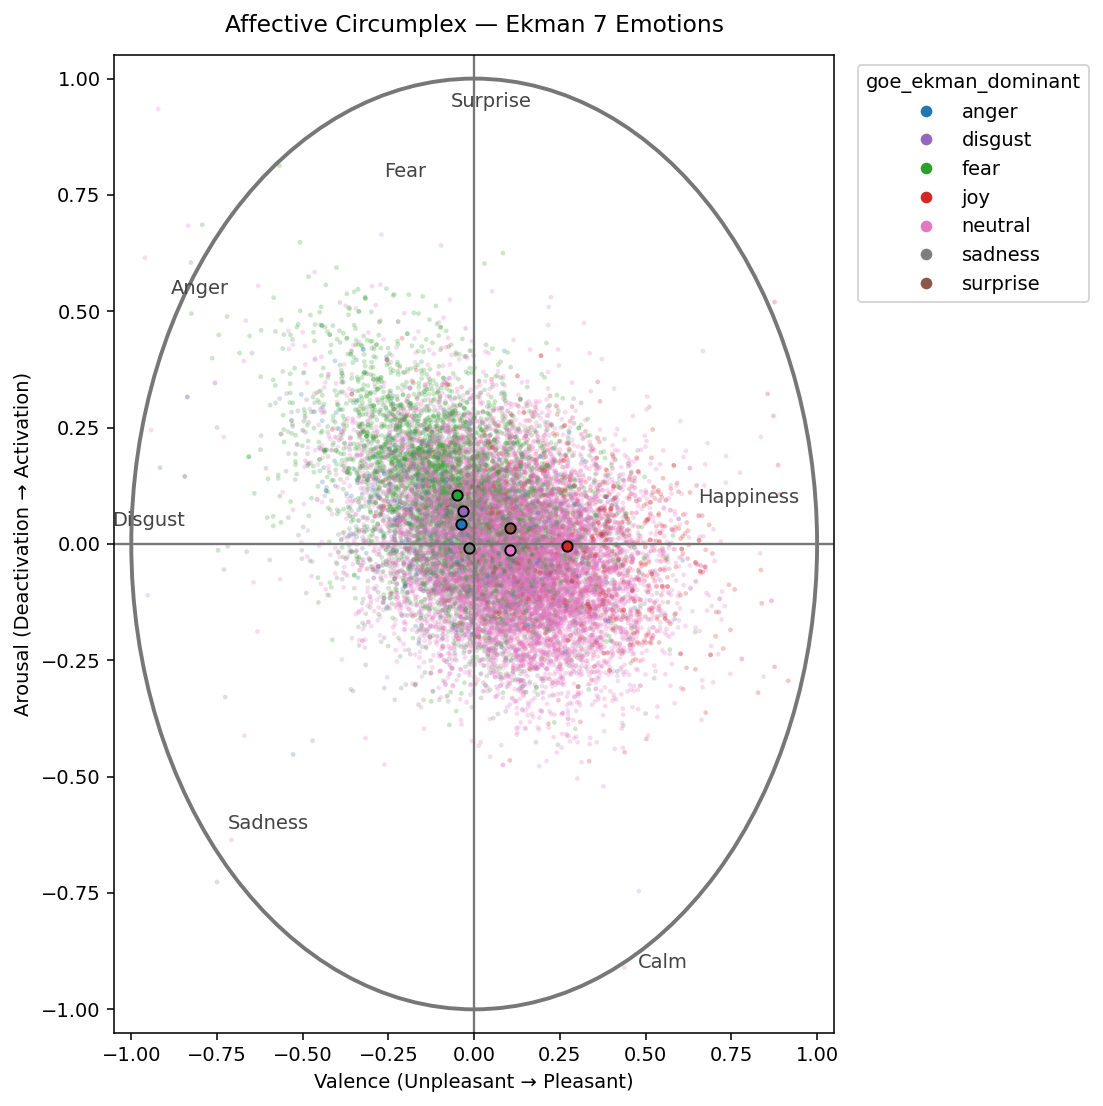

/var/folders/x7/xrth4_p955x331lrb98xvffh0000gn/T/ipykernel_57450/2329874174.py:131: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", max(8, len(unique_goe)))


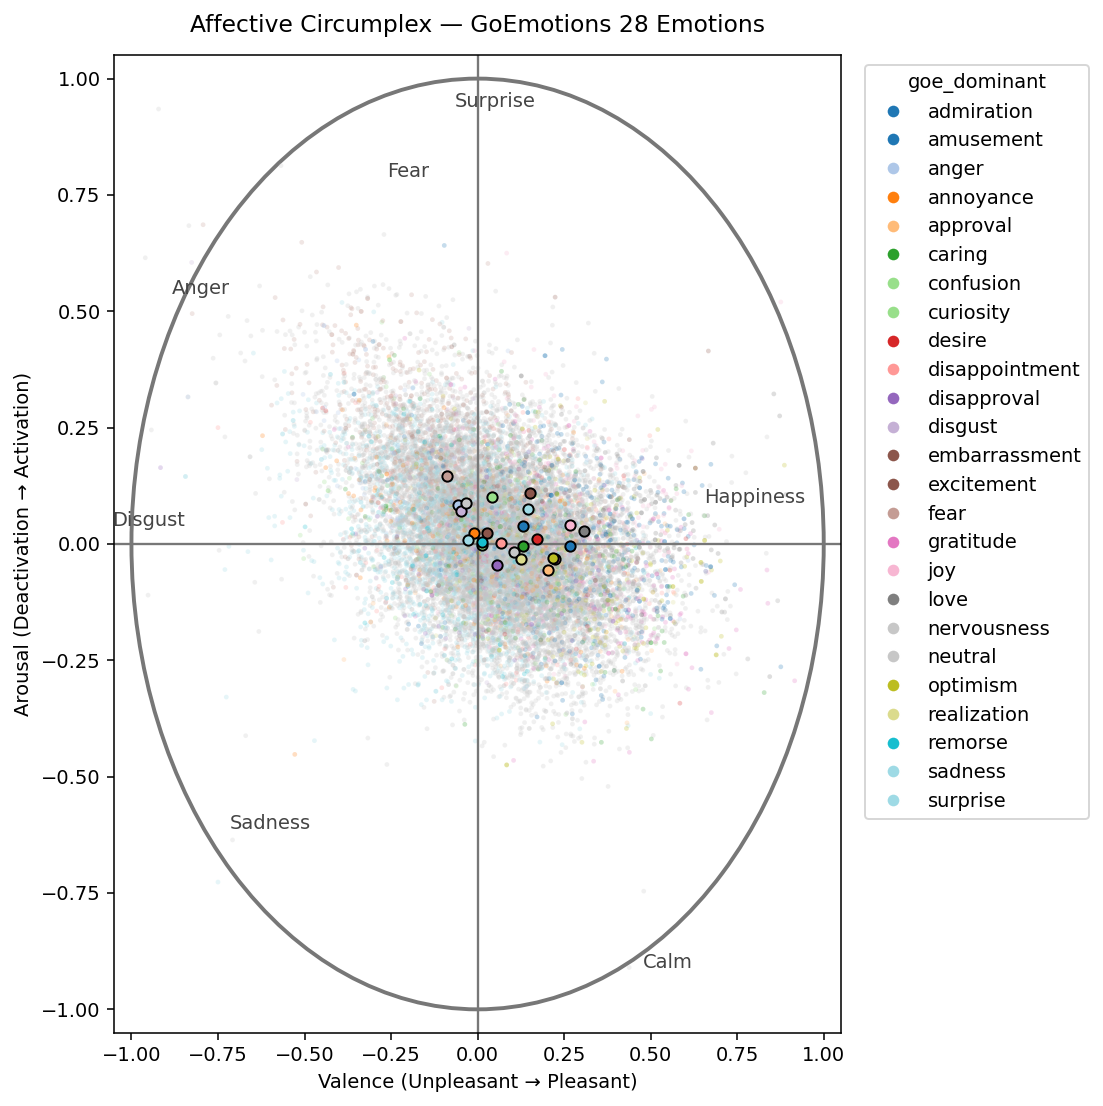


Ekman 7 — summary (sorted by n):
 Emotion     n  mean_val  mean_aro
 neutral 11094     0.105    -0.014
    fear  3926    -0.051     0.106
 sadness  1829    -0.015    -0.009
     joy   892     0.270    -0.004
   anger   295    -0.038     0.042
 disgust   115    -0.034     0.070
surprise    91     0.104     0.034

GoEmotions 28 — summary (sorted by n):
       Emotion    n  mean_val  mean_aro
       neutral 8530     0.106    -0.018
       sadness 2749    -0.026     0.008
   nervousness 2574    -0.032     0.089
          fear 1033    -0.088     0.145
    admiration  442     0.266    -0.004
      optimism  319     0.217    -0.031
     gratitude  316     0.225    -0.032
           joy  270     0.266     0.040
          love  264     0.307     0.028
disappointment  247     0.068     0.001
        caring  222     0.131    -0.005
     annoyance  201    -0.011     0.023
       remorse  182     0.012     0.005
     confusion  144     0.012    -0.002
         anger  133    -0.057     0.085
      

In [13]:
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Config =====
VAL_COL = "va_val_std"
ARO_COL = "va_aro_std"
QUAD_COL = "va_quadrant"  # not shown on plot; used only for summaries
EKMAN_COL = "goe_ekman_dominant"
GOE_CANDIDATES = ["goe_dominant", "goe_emotion", "goe_ekman_dominant"]
MAX_N = 30000
RS = np.random.RandomState(42)

anchors = {
    "Happiness": (0.80, 0.10),
    "Calm":      (0.55,-0.90),
    "Sadness":   (-0.60,-0.60),
    "Anger":     (-0.80, 0.55),
    "Disgust":   (-0.95, 0.05),
    "Fear":      (-0.20, 0.80),
    "Surprise":  (0.05, 0.95),
}

ekman_palette = {
    "anger":   "#1f77b4",
    "disgust": "#9467bd",
    "fear":    "#2ca02c",
    "joy":     "#d62728",
    "sadness": "#7f7f7f",
    "surprise":"#8c564b",
    "neutral": "#e377c2",
}

def detect_goe_col(df):
    for c in GOE_CANDIDATES:
        if c in df.columns:
            return c
    return None

def prepare_sample(df, label_col):
    sub = df[[VAL_COL, ARO_COL, label_col]].dropna()
    if len(sub) > MAX_N:
        sub = sub.iloc[RS.choice(len(sub), size=MAX_N, replace=False)]
    return sub

def plot_circumplex_simple(df, label_col, title, palette=None):
    sub = prepare_sample(df, label_col)
    if sub.empty:
        print(f"No data for {label_col} — skipping.")
        return None, None

    labels = sub[label_col].astype(str).fillna("unknown")
    unique = labels.unique()

    # Colors
    if palette is None:
        cmap = plt.cm.get_cmap("tab20", max(8, len(unique)))
        color_map = {lab: cmap(i) for i, lab in enumerate(unique)}
    else:
        # palette keys should be lowercase for consistent lookup
        color_map = {lab: palette.get(str(lab).lower(), "#AAAAAA") for lab in unique}

    fig, ax = plt.subplots(figsize=(8, 8), dpi=140)

    # Single circumplex circle + axes
    circle = plt.Circle((0,0), 1.0, edgecolor="#777777", facecolor="none", lw=2)
    ax.add_artist(circle)
    ax.axhline(0, color="#777777", lw=1.2)
    ax.axvline(0, color="#777777", lw=1.2)
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.set_xlabel("Valence (Unpleasant → Pleasant)")
    ax.set_ylabel("Arousal (Deactivation → Activation)")

    # Rim anchors (labels around the circle)
    for name, (px, py) in anchors.items():
        ax.text(px, py, name, fontsize=10, color="#444", ha="center", va="center")

    # Scatter
    cols = labels.map(lambda l: color_map.get(l, "#AAAAAA")).values
    ax.scatter(sub[VAL_COL], sub[ARO_COL], s=6, alpha=0.25, c=cols, edgecolors="none")

    # (Optional) small centroids — keep for orientation; remove if unwanted
    rows = []
    for lab, grp in sub.groupby(label_col):
        x = grp[VAL_COL].astype(float).values
        y = grp[ARO_COL].astype(float).values
        if len(x) == 0: 
            continue
        meanx, meany = float(np.mean(x)), float(np.mean(y))
        ax.scatter([meanx], [meany], s=28, color=color_map.get(lab, "#333333"), edgecolor="k", zorder=5)
        rows.append((lab, len(grp), meanx, meany))

    # Simple legend: emotions only (no quadrant or other text)
    handles = [Line2D([0],[0], marker='o', color='w',
                      markerfacecolor=color_map.get(lab,"#333333"),
                      markersize=7, label=str(lab)) for lab in sorted(unique)]
    ax.legend(handles=handles, title=label_col, bbox_to_anchor=(1.02, 1.0),
              loc="upper left", frameon=True)
    ax.set_title(title, pad=12)
    plt.tight_layout()

    summary = pd.DataFrame(rows, columns=["Emotion","n","mean_val","mean_aro"]).sort_values("n", ascending=False)
    return fig, summary

# Use df_beyondblue for plotting and summaries
df = df_beyondblue

# ===== Ekman 7 =====
if EKMAN_COL in df.columns:
    ekman_sub = df[[VAL_COL, ARO_COL, EKMAN_COL]].dropna()
    if not ekman_sub.empty:
        fig1, summary_ekman = plot_circumplex_simple(df, EKMAN_COL,
                                                     "Affective Circumplex — Ekman 7 Emotions",
                                                     palette=ekman_palette)
        plt.show()
    else:
        print("No complete Ekman-labeled rows found.")
        summary_ekman = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])
else:
    print(f"Column '{EKMAN_COL}' not found; skipping Ekman plot.")
    summary_ekman = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])

# ===== GoEmotions 28 =====
goe_col = detect_goe_col(df)
if goe_col and goe_col in df.columns:
    goe_sub = df[[VAL_COL, ARO_COL, goe_col]].dropna()
    if not goe_sub.empty:
        unique_goe = np.unique(goe_sub[goe_col].astype(str))
        cmap = plt.cm.get_cmap("tab20", max(8, len(unique_goe)))
        # ensure palette keys are lowercase to match lookup in plot_circumplex_simple
        palette_goe = {str(lab).lower(): cmap(i % cmap.N) for i, lab in enumerate(unique_goe)}
        fig2, summary_goe = plot_circumplex_simple(df, goe_col,
                                                   "Affective Circumplex — GoEmotions 28 Emotions",
                                                   palette=palette_goe)
        plt.show()
    else:
        print("No complete GoEmotions-labeled rows found.")
        summary_goe = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])
else:
    print("No GoEmotions label column detected; skipping GoEmotions plot.")
    summary_goe = pd.DataFrame(columns=["Emotion","n","mean_val","mean_aro"])

# ===== Print summaries (no quadrant text) =====
pd.set_option("display.max_rows", 200)
print("\nEkman 7 — summary (sorted by n):")
if not summary_ekman.empty:
    out_ek = summary_ekman.copy()
    out_ek["mean_val"] = out_ek["mean_val"].round(3)
    out_ek["mean_aro"] = out_ek["mean_aro"].round(3)
    print(out_ek.reset_index(drop=True).to_string(index=False))
else:
    print("No Ekman summary available.")

print("\nGoEmotions 28 — summary (sorted by n):")
if 'summary_goe' in locals() and not summary_goe.empty:
    out_goe = summary_goe.copy()
    out_goe["mean_val"] = out_goe["mean_val"].round(3)
    out_goe["mean_aro"] = out_goe["mean_aro"].round(3)
    print(out_goe.reset_index(drop=True).to_string(index=False))
else:
    print("No GoEmotions summary available.")


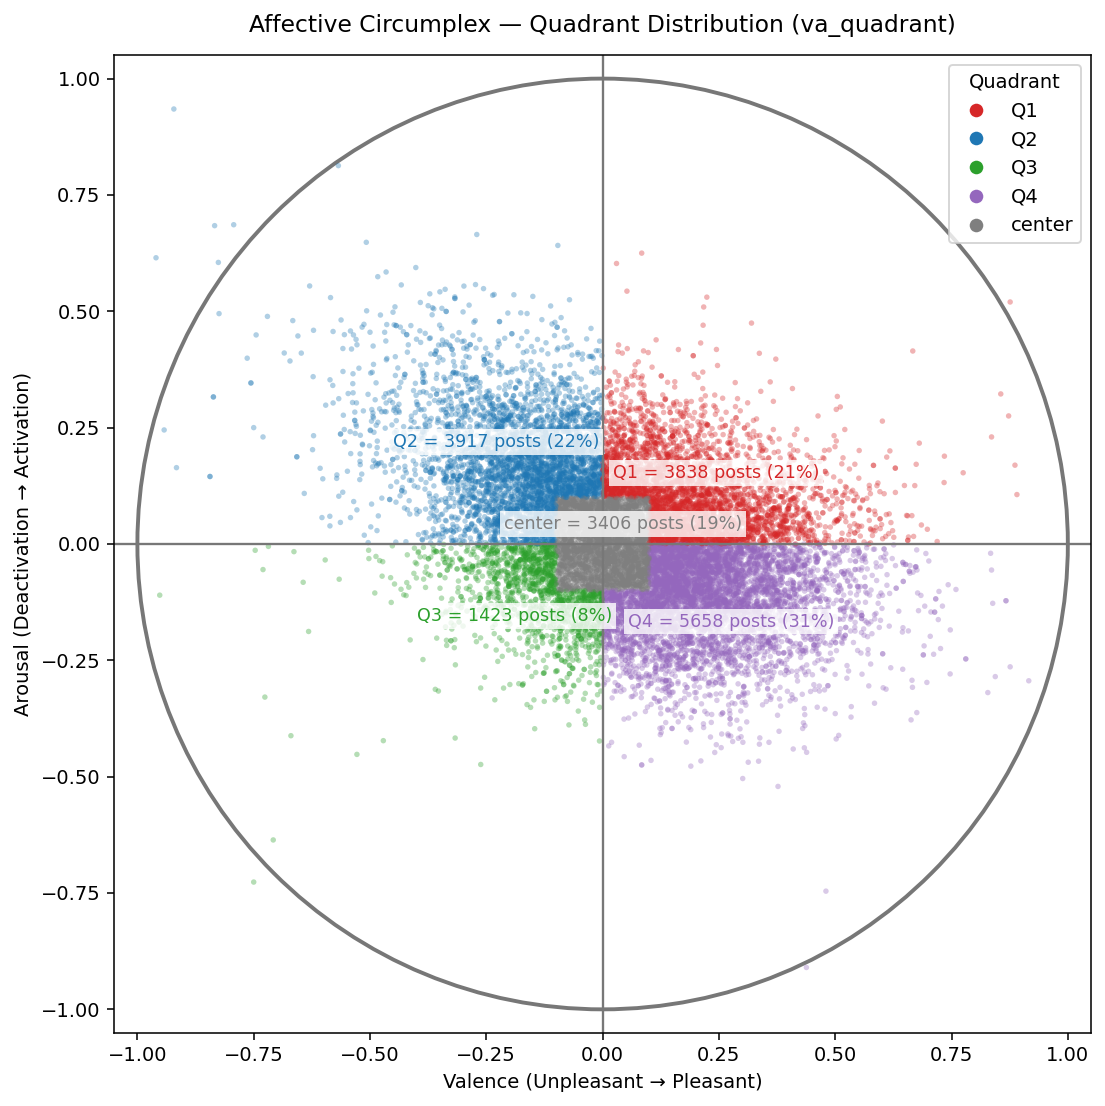

Quadrant    n  % of total  mean_valence  mean_arousal
      Q4 5658        31.0         0.236        -0.127
      Q2 3917        21.5        -0.189         0.180
      Q1 3838        21.0         0.203         0.112
  center 3406        18.7         0.004         0.004
      Q3 1423         7.8        -0.150        -0.115


In [15]:
from matplotlib.lines import Line2D

# Quadrant-based circumplex visualization + summary (single cell)
# Uses existing variables: df_beyondblue, np, pd, plt

# 1) Prepare data: drop missing valence/arousal and require a quadrant label
df_q = df_beyondblue[["va_val_std", "va_aro_std", "va_quadrant"]].copy()
df_q = df_q.dropna(subset=["va_val_std", "va_aro_std"])
df_q = df_q[df_q["va_quadrant"].notna()].copy()

# 2) Subsample (<= 30000) with fixed seed
MAX_N = 30000
rng = np.random.RandomState(42)
if len(df_q) > MAX_N:
    df_q = df_q.sample(n=MAX_N, random_state=rng).reset_index(drop=True)

# 3) Color palette for quadrants
palette = {
    "Q1": "#d62728",      # red
    "Q2": "#1f77b4",      # blue
    "Q3": "#2ca02c",      # green
    "Q4": "#9467bd",      # purple
    "center": "#7f7f7f",  # gray
}
# Normalize quadrant strings
df_q["va_quadrant"] = df_q["va_quadrant"].astype(str).map(lambda s: s.strip())

# 4) Plot setup
fig, ax = plt.subplots(figsize=(8, 8), dpi=140)

# Circle and cross-axes
circle = plt.Circle((0, 0), 1.0, edgecolor="#777777", facecolor="none", lw=2)
ax.add_artist(circle)
ax.axhline(0, color="#777777", lw=1.2)
ax.axvline(0, color="#777777", lw=1.2)

# 5) Scatter by quadrant
colors = df_q["va_quadrant"].map(lambda q: palette.get(q, "#AAAAAA"))
ax.scatter(df_q["va_val_std"], df_q["va_aro_std"], s=8, alpha=0.35, c=colors, edgecolors="none")

# 6) Compute per-quadrant stats
total = len(df_q)
grp = df_q.groupby("va_quadrant")[["va_val_std", "va_aro_std"]].agg(["count", "mean"])
grp.columns = ["_".join(col).strip() for col in grp.columns.values]
summary = grp.reset_index().rename(columns={
    "va_val_std_count": "n",
    "va_val_std_mean": "mean_valence",
    "va_aro_std_mean": "mean_arousal"
})
summary["pct"] = (summary["n"] / total * 100.0).round(1)

# 7) Annotate centroids on plot
for _, row in summary.iterrows():
    q = row["va_quadrant"]
    mean_x = row["mean_valence"]
    mean_y = row["mean_arousal"]
    n = int(row["n"])
    pct = float(row["pct"])
    label_text = f"{q} = {n} posts ({int(round(pct))}%)"
    dx = 0.04 if mean_x >= 0 else -0.04
    dy = 0.04 if mean_y >= 0 else -0.04
    ax.text(mean_x + dx, mean_y + dy, label_text,
            fontsize=9, color=palette.get(q, "#333333"),
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=2),
            ha="center", va="center")

# 8) Axes limits & labels & title
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("Valence (Unpleasant → Pleasant)")
ax.set_ylabel("Arousal (Deactivation → Activation)")
ax.set_title("Affective Circumplex — Quadrant Distribution (va_quadrant)", pad=12)

# 9) Simple legend
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=col, markersize=8, label=lab)
           for lab, col in palette.items()]
ax.legend(handles=handles, title="Quadrant", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# 10) Print summary table sorted by count (descending)
out = summary[["va_quadrant", "n", "pct", "mean_valence", "mean_arousal"]].copy()
out = out.rename(columns={"va_quadrant": "Quadrant", "pct": "% of total"})
out["mean_valence"] = out["mean_valence"].round(3)
out["mean_arousal"] = out["mean_arousal"].round(3)
out = out.sort_values("n", ascending=False).reset_index(drop=True)
print(out.to_string(index=False))


In [14]:
#convert to csv
df_beyondblue.to_csv('beyondblue_nrc.csv', index=False)